# CS2 Market Analysis Project
### Serkan Dağ - DSA 210 Milestone 1

1. Veriler yükleniyor...
2. Dev Turnuva Takvimi veri setine işleniyor...
✅ Tablo zenginleştirildi: 'enriched_market_data.csv' hazır.
------------------------------------------------------------
3. Çift Eksenli EDA Grafiği çiziliyor...
✅ EFSANE GRAFİK 'final_tournament_twitch_impact.png' olarak kaydedildi!


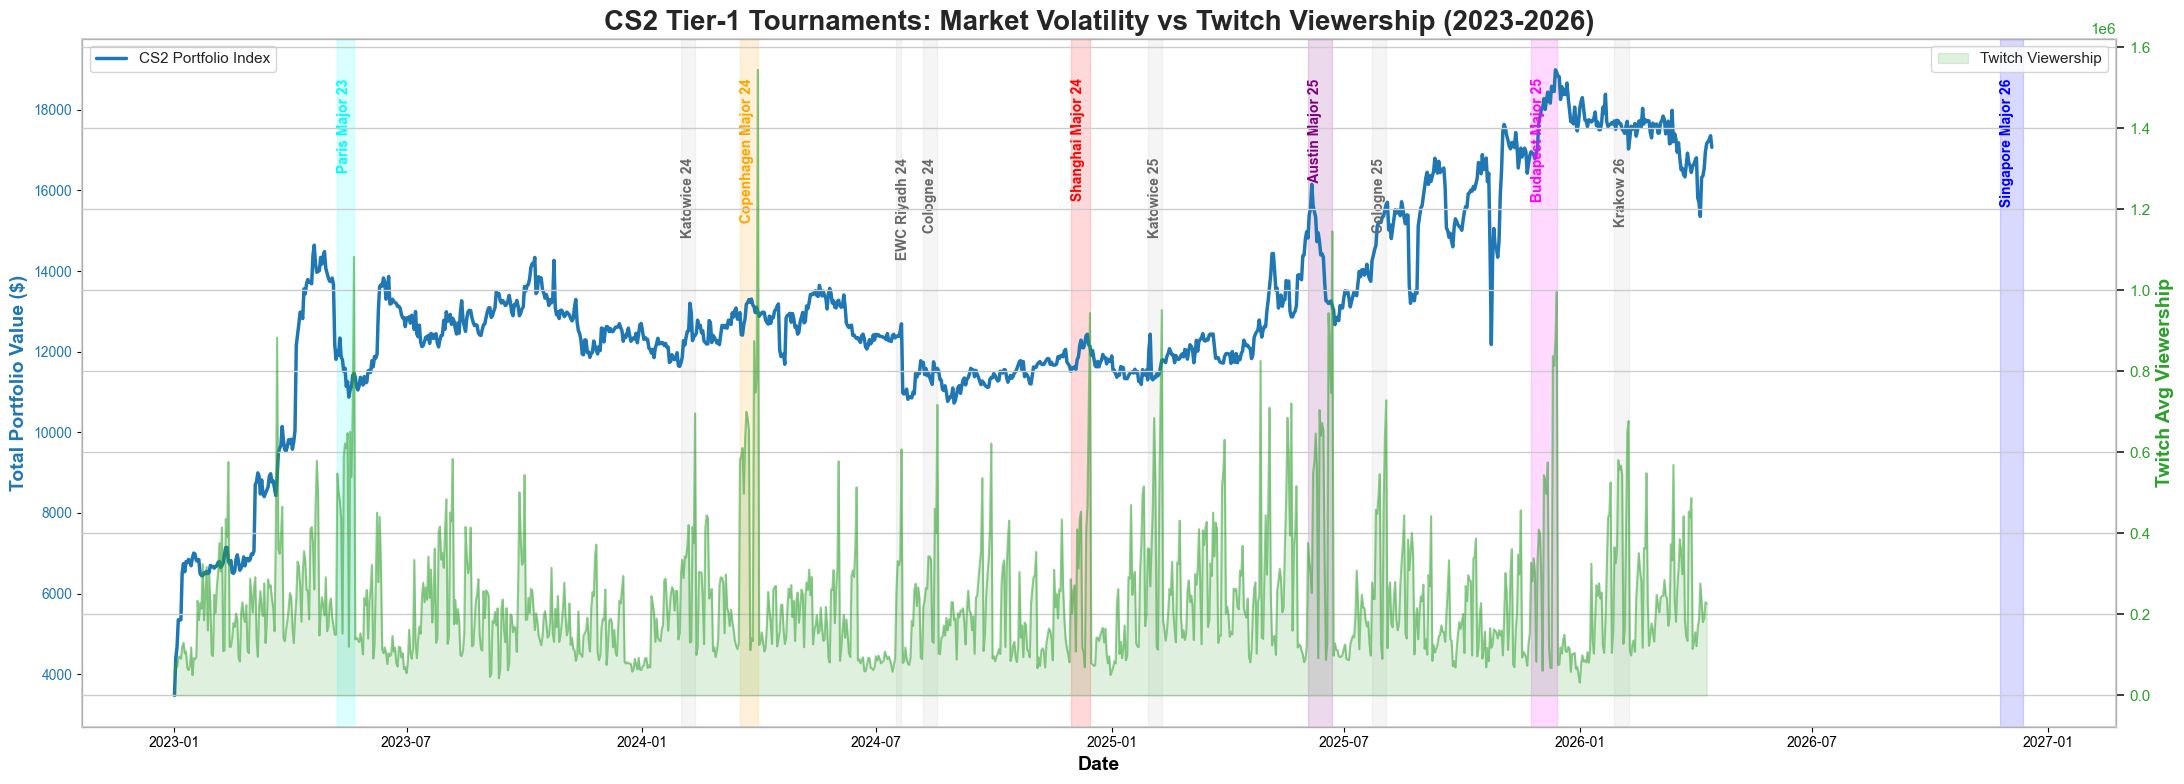

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. VERİLERİ YÜKLE
csv_file = "dsa210_mega_data.csv" 
twitch_file = "cs2_gunluk_izleyici.csv"

print("1. Veriler yükleniyor...")
try:
    df_market = pd.read_csv(csv_file)
    df_twitch = pd.read_csv(twitch_file)
except FileNotFoundError as e:
    print(f"HATA: Dosya bulunamadı! {e}")
    exit()

df_market['date'] = pd.to_datetime(df_market['date'])
df_twitch['date'] = pd.to_datetime(df_twitch['tarih']).dt.tz_localize(None).dt.normalize()

df = pd.merge(df_market, df_twitch[['date', 'ort_izleyici']], on='date', how='left')

# ==========================================
# 2. DEV TURNUVA TAKVİMİ (DATA ENRICHMENT)
# ==========================================
print("2. Dev Turnuva Takvimi veri setine işleniyor...")

# Turnuvalar: (Başlangıç, Bitiş, İsim, Grafik Rengi, Yazı Yüksekliği Ayarı)
turnuvalar = [
    # MAJOR TURNUVALAR (Renkli)
    ('2023-05-08', '2023-05-21', 'Paris Major 23', 'cyan', 0.95),
    ('2024-03-17', '2024-03-31', 'Copenhagen Major 24', 'orange', 0.95),
    ('2024-11-30', '2024-12-15', 'Shanghai Major 24', 'red', 0.95),
    ('2025-06-03', '2025-06-22', 'Austin Major 25', 'purple', 0.95),
    ('2025-11-24', '2025-12-14', 'Budapest Major 25', 'magenta', 0.95),
    ('2026-11-25', '2026-12-13', 'Singapore Major 26', 'blue', 0.95),
    
    # S-TIER DEV TURNUVALAR (Arka Planı Boğmamak İçin Gri)
    ('2024-01-31', '2024-02-11', 'Katowice 24', 'gray', 0.85),
    ('2024-07-17', '2024-07-21', 'EWC Riyadh 24', 'gray', 0.85),
    ('2024-08-07', '2024-08-18', 'Cologne 24', 'gray', 0.85),
    ('2025-01-29', '2025-02-09', 'Katowice 25', 'gray', 0.85),
    ('2025-07-23', '2025-08-03', 'Cologne 25', 'gray', 0.85),
    ('2026-01-28', '2026-02-08', 'Krakow 26', 'gray', 0.85)
]

# Tabloya etiketleme fonksiyonu
def get_tournament_name(date_val):
    for baslangic, bitis, isim, _, _ in turnuvalar:
        if pd.to_datetime(baslangic) <= date_val <= pd.to_datetime(bitis):
            return isim
    return 'Normal Period'

df['Tournament'] = df['date'].apply(get_tournament_name)

enriched_file = "enriched_market_data.csv"
df.to_csv(enriched_file, index=False)
print(f"✅ Tablo zenginleştirildi: '{enriched_file}' hazır.")
print("-" * 60)

# ==========================================
# 3. KUSURSUZ ÇİFT EKSENLİ GRAFİK (EDA)
# ==========================================
print("3. Çift Eksenli EDA Grafiği çiziliyor...")

# TOPLAM PORTFÖY DEĞERİ (SUM)
item_columns = [col for col in df.columns if col not in ['date', 'Tournament', 'ort_izleyici', 'tarih']]
df['Market_Index'] = df[item_columns].sum(axis=1)

# Çizim Ayarları (Genişliği iyice artırdık ki tarihler sıkışmasın)
fig, ax1 = plt.subplots(figsize=(22, 8)) 
sns.set_theme(style="whitegrid")

# SOL EKSEN: PİYASA PORTFÖYÜ
color1 = '#1f77b4'
ax1.set_xlabel('Date', fontsize=14, fontweight='bold')
ax1.set_ylabel('Total Portfolio Value ($)', color=color1, fontsize=14, fontweight='bold')
sns.lineplot(data=df, x='date', y='Market_Index', ax=ax1, color=color1, linewidth=2.5, label='CS2 Portfolio Index')
ax1.tick_params(axis='y', labelcolor=color1)

# SAĞ EKSEN: TWITCH İZLEYİCİSİ
ax2 = ax1.twinx()  
color2 = '#2ca02c'
ax2.set_ylabel('Twitch Avg Viewership', color=color2, fontsize=14, fontweight='bold')
ax2.fill_between(df['date'], df['ort_izleyici'], color=color2, alpha=0.15, label='Twitch Viewership')
sns.lineplot(data=df, x='date', y='ort_izleyici', ax=ax2, color=color2, alpha=0.5)
ax2.tick_params(axis='y', labelcolor=color2)

# TURNUVA GÖLGELENDİRMELERİ (Döngü ile efsanevi çizim)
for baslangic, bitis, isim, renk, y_pos in turnuvalar:
    start_dt = pd.to_datetime(baslangic)
    end_dt = pd.to_datetime(bitis)
    
    # Arka plan gölgesi (S-Tier için daha şeffaf, Major için belirgin)
    alpha_val = 0.15 if renk != 'gray' else 0.08
    ax1.axvspan(start_dt, end_dt, color=renk, alpha=alpha_val)
    
    # İsimleri üst üste binmesin diye hizalıyoruz
    ax1.text(start_dt, ax1.get_ylim()[1] * y_pos, f' {isim}', color=renk if renk != 'gray' else 'dimgray', 
             fontweight='bold', rotation=90, va='top', fontsize=10)

plt.title('CS2 Tier-1 Tournaments: Market Volatility vs Twitch Viewership (2023-2026)', fontsize=20, fontweight='bold')
fig.tight_layout()

# Grafiği Kaydet ve Göster
plt.savefig('final_tournament_twitch_impact.png', dpi=300)
print("✅ EFSANE GRAFİK 'final_tournament_twitch_impact.png' olarak kaydedildi!")
plt.show()

🏆 DSA 210 - FİNAL PROJESİ İSTATİSTİK VE ML RAPORU 🏆

--- 1. HİPOTEZ TESTLERİ ---
📌 Pearson Korelasyonu (r): 0.0717
   P-Value: 1.3168e-02
   👉 SONUÇ: P-Value < 0.05. H0 REDDEDİLDİ! İzleyici sayısı ile piyasa değeri arasında anlamlı bir ilişki var.

📌 T-Testi (Turnuva vs Normal Dönem Oynaklığı):
   T-Statistik Değeri: 4.6776
   P-Value: 5.2979e-06
   👉 SONUÇ: P-Value < 0.05. H0 REDDEDİLDİ! Turnuva dönemlerindeki fiyatlar normal dönemlerden istatistiksel olarak farklıdır.

--- 2. MAKİNE ÖĞRENMESİ (PREDICTIVE MODELING) ---
📌 Model Başarısı (R-Squared): -0.1859 (Fiyatlardaki değişimin %-18.6'ini açıklıyor)
📌 Ortalama Mutlak Hata (MAE): $1916.68

✅ Grafikler 'ml_analysis_results.png' olarak kaydedildi!


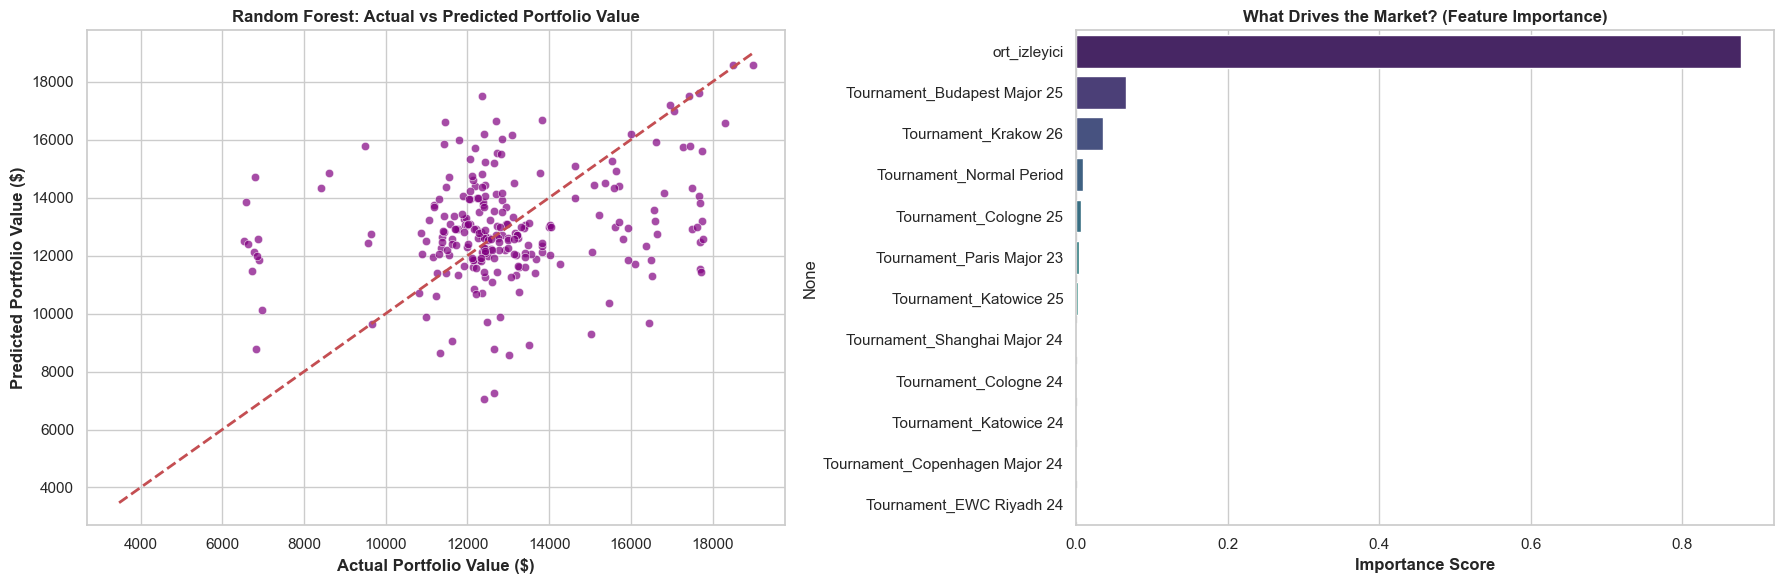

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# 1. ZENGİNLEŞTİRİLMİŞ VERİYİ YÜKLE
df = pd.read_csv("enriched_market_data.csv")
df['date'] = pd.to_datetime(df['date'])

# --- EKSİK OLAN MARKET_INDEX HESAPLAMASI BURAYA EKLENDİ ---
# Item sütunlarını bul (Tarih, Turnuva ve İzleyici dışındakiler)
item_columns = [col for col in df.columns if col not in ['date', 'Tournament', 'ort_izleyici', 'tarih']]
# Toplam Portföy Değerini (Sum) hesapla
df['Market_Index'] = df[item_columns].sum(axis=1)

# Eksik (NaN) izleyici verisi olan (mesela turnuvanın oynanmadığı boş günler) satırları temizle
df = df.dropna(subset=['Market_Index', 'ort_izleyici'])

print("="*60)
print("🏆 DSA 210 - FİNAL PROJESİ İSTATİSTİK VE ML RAPORU 🏆")
print("="*60)

# ==========================================
# ADIM 1: HİPOTEZ TESTİ (HYPOTHESIS TESTING)
# ==========================================
print("\n--- 1. HİPOTEZ TESTLERİ ---")

# Test 1: Pearson Korelasyonu (İzleyici vs Fiyat)
corr, p_value_corr = stats.pearsonr(df['ort_izleyici'], df['Market_Index'])
print(f"📌 Pearson Korelasyonu (r): {corr:.4f}")
print(f"   P-Value: {p_value_corr:.4e}")
if p_value_corr < 0.05:
    print("   👉 SONUÇ: P-Value < 0.05. H0 REDDEDİLDİ! İzleyici sayısı ile piyasa değeri arasında anlamlı bir ilişki var.")
else:
    print("   👉 SONUÇ: Anlamlı bir ilişki bulunamadı.")

# Test 2: T-Test (Turnuva Dönemi vs Normal Dönem)
tournament_prices = df[df['Tournament'] != 'Normal Period']['Market_Index']
normal_prices = df[df['Tournament'] == 'Normal Period']['Market_Index']

t_stat, p_value_t = stats.ttest_ind(tournament_prices, normal_prices, equal_var=False)
print(f"\n📌 T-Testi (Turnuva vs Normal Dönem Oynaklığı):")
print(f"   T-Statistik Değeri: {t_stat:.4f}")
print(f"   P-Value: {p_value_t:.4e}")
if p_value_t < 0.05:
    print("   👉 SONUÇ: P-Value < 0.05. H0 REDDEDİLDİ! Turnuva dönemlerindeki fiyatlar normal dönemlerden istatistiksel olarak farklıdır.")
else:
    print("   👉 SONUÇ: Turnuva dönemleri ile normal dönemler arasında anlamlı fiyat farkı yoktur.")

# ==========================================
# ADIM 2: MAKİNE ÖĞRENMESİ (RANDOM FOREST)
# ==========================================
print("\n--- 2. MAKİNE ÖĞRENMESİ (PREDICTIVE MODELING) ---")

# Makine turnuva isimlerini (Yazı) anlayabilsin diye One-Hot Encoding yapıyoruz
X = pd.get_dummies(df[['ort_izleyici', 'Tournament']], drop_first=True)
y = df['Market_Index']

# Train-Test Split (%80 Eğitim, %20 Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Modeli
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Tahmin
y_pred = rf_model.predict(X_test)

# Metrikler
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"📌 Model Başarısı (R-Squared): {r2:.4f} (Fiyatlardaki değişimin %{r2*100:.1f}'ini açıklıyor)")
print(f"📌 Ortalama Mutlak Hata (MAE): ${mae:.2f}")

# ==========================================
# ADIM 3: ML GRAFİKLERİ
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Grafik 1: Gerçek vs Tahmin
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='purple', ax=ax1)
ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) 
ax1.set_title('Random Forest: Actual vs Predicted Portfolio Value', fontweight='bold')
ax1.set_xlabel('Actual Portfolio Value ($)', fontweight='bold')
ax1.set_ylabel('Predicted Portfolio Value ($)', fontweight='bold')

# Grafik 2: Değişken Önemi (Feature Importance)
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis', ax=ax2)
ax2.set_title('What Drives the Market? (Feature Importance)', fontweight='bold')
ax2.set_xlabel('Importance Score', fontweight='bold')

plt.tight_layout()
plt.savefig('ml_analysis_results.png', dpi=300)
print("\n✅ Grafikler 'ml_analysis_results.png' olarak kaydedildi!")
print("="*60)
plt.show()